# PPG vs PPO parity (full ant, variable sampled morphs)

Dual-network PPG vs the **single-network** variant (one shared trunk, value gradient detached at the trunk in the policy phase; PPG paper sec 3.6). PPO shown for reference when present.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data/ppg_parity')
D = np.load(DATA / 'curves.npz')
I = np.load(DATA / 'inference.npz')
seeds = list(D['seeds'])
algos = [str(a) for a in D['algos']]
COLORS = {'ppo': 'C0', 'ppg': 'C1', 'ppg_single': 'C2'}
LABELS = {'ppo': 'PPO', 'ppg': 'PPG (dual)', 'ppg_single': 'PPG (single)'}
lab = lambda a: LABELS.get(a, a.upper())
print('seeds', seeds, '| algos', algos)

def series(algo, tag):
    """(steps, M[n_seeds, T]) for a tag across seeds; None if absent. Truncates to min T."""
    tg = tag.replace('/', '_')
    cols, steps = [], None
    for s in seeds:
        k = f'{algo}_s{s}__{tg}'
        if k + '__val' in D.files:
            cols.append(D[k + '__val'])
            st = D[k + '__step']
            steps = st if steps is None or len(st) < len(steps) else steps
    if not cols:
        return None, None
    T = min(len(c) for c in cols)
    return steps[:T], np.stack([c[:T] for c in cols])

def band(ax, algo, tag, label=None, warmup=1):
    x, M = series(algo, tag)
    if x is None:
        return False
    x, M = x[warmup:], M[:, warmup:]
    m, sd = M.mean(0), M.std(0)
    ax.plot(x, m, color=COLORS[algo], label=label or lab(algo))
    ax.fill_between(x, m - sd, m + sd, color=COLORS[algo], alpha=0.2)
    return True


## 1. Performance over time

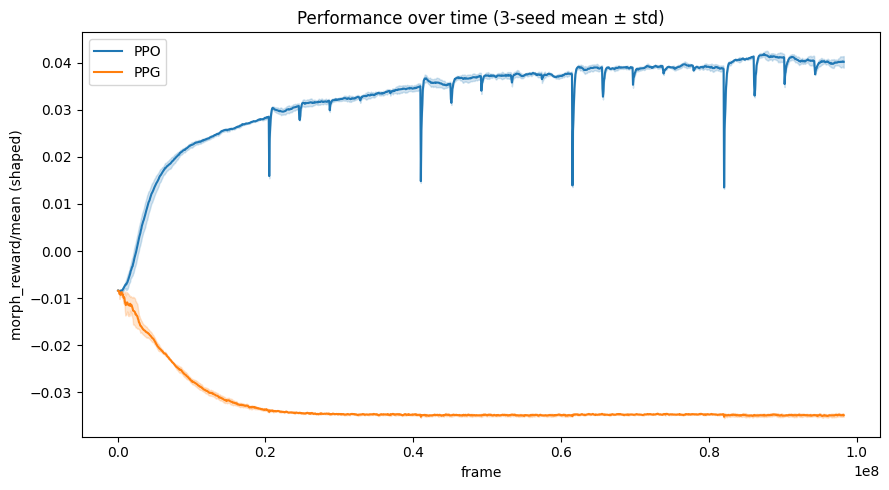

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
for a in algos:
    band(ax, a, 'morph_reward/mean')
ax.set_xlabel('frame'); ax.set_ylabel('morph_reward/mean (shaped)')
ax.set_title('Performance over time (3-seed mean ± std)')
ax.legend(); plt.tight_layout()

## 2. Losses over time

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for a in algos:
    band(axs[0], a, 'losses/a_loss'); band(axs[1], a, 'losses/c_loss')
axs[0].set_title('actor loss'); axs[1].set_title('critic loss')
for ax in axs[:2]:
    ax.set_xlabel('frame'); ax.legend()
# aux losses, per PPG variant (single-net aux_value_net == aux_value)
for a in algos:
    if a == 'ppo':
        continue
    for tag, suf, ls in [('losses/aux_value', 'aux_value', '-'),
                         ('losses/aux_clone_kl', 'clone KL', '--')]:
        x, M = series(a, tag)
        if x is not None:
            axs[2].plot(x, M.mean(0), ls, color=COLORS[a], label=f'{lab(a)} {suf}')
axs[2].set_title('PPG aux losses'); axs[2].set_xlabel('frame'); axs[2].legend()
plt.tight_layout()


## 3. Phase timing

Steady-state per-epoch seconds (median over epochs, mean over seeds). `t_aux` is
logged only on aux-phase epochs (every `n_pi`); the amortized bar divides it by `n_pi`.

In [ ]:
N_PI = 32  # amortization window for t_aux

def med(algo, tag):
    x, M = series(algo, tag)
    return float(np.median(M[:, 1:])) if x is not None else 0.0  # drop epoch0 warmup

PHASES = [('rollout', 'perf/t_rollout', 1), ('update', 'perf/t_update', 1),
          ('policy', 'perf/t_policy', 1), ('value', 'perf/t_value', 1),
          ('aux/n_pi', 'perf/t_aux', N_PI)]
PHASE_COLOR = {name: f'C{i}' for i, (name, _, _) in enumerate(PHASES)}
times = {a: {k: med(a, t) / d for k, t, d in PHASES if med(a, t) > 0} for a in algos}

fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(algos)), 5))
seen = set()
def stack(x, parts):
    bottom = 0
    for k, v in parts.items():
        ax.bar(x, v, 0.6, bottom=bottom, color=PHASE_COLOR[k],
               label=(k if k not in seen else None)); seen.add(k)
        ax.text(x, bottom + v / 2, f'{k}\n{v:.3f}', ha='center', va='center', fontsize=8)
        bottom += v
    return bottom
tots = [stack(j, times[a]) for j, a in enumerate(algos)]
ax.set_xticks(range(len(algos)))
ax.set_xticklabels([f'{lab(a)}\n{t:.3f}s' for a, t in zip(algos, tots)])
ax.set_ylabel('seconds / epoch (amortized)')
ax.set_title('Per-epoch phase timing (steady-state)')
ax.legend(); plt.tight_layout()
for a in algos:
    print(lab(a), {k: round(v, 4) for k, v in times[a].items()})


## 4. Final-inference return (all 131 stable bodies, deterministic mu)

In [ ]:
lc = I['bodies_legcount']
ret = {a: I[f'ret_{a}'] for a in algos if f'ret_{a}' in I.files}  # (n_seeds, n_bodies)

# overall: per-seed mean over bodies -> mean +/- std over seeds
print('Final-inference return (mean over bodies):')
for a, R in ret.items():
    per_seed = R.mean(1)
    print(f'  {lab(a):14s}  {per_seed.mean():8.1f} +/- {per_seed.std():6.1f}   per-seed {np.round(per_seed,1)}')

counts = sorted(set(int(c) for c in lc))
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(counts)); w = 0.8 / max(len(ret), 1)
for j, (a, R) in enumerate(ret.items()):
    means = [R[:, lc == c].mean() for c in counts]
    errs = [R[:, lc == c].mean(1).std() for c in counts]
    ax.bar(x + (j - (len(ret) - 1) / 2) * w, means, w, yerr=errs, label=lab(a), color=COLORS[a])
ax.set_xticks(x); ax.set_xticklabels(counts)
ax.set_xlabel('leg count'); ax.set_ylabel('mean return')
ax.set_title('Final-inference return per leg-count (seed mean ± std)')
ax.legend(); plt.tight_layout()


## 5. Peak GPU memory

The single-network's motivation: recover dual-net's ~2× footprint. Run peak = max over the run; reused dual runs predate this metric and may be absent.

In [ ]:
fig, ax = plt.subplots(figsize=(max(5, 2 * len(algos)), 5))
peak = {}
for a in algos:
    x, M = series(a, 'perf/peak_mem_mib')
    if x is None:
        continue
    per_seed = M.max(1)                      # run peak per seed
    peak[a] = (per_seed.mean(), per_seed.std())
xs = list(peak)
ax.bar(range(len(xs)), [peak[a][0] for a in xs], yerr=[peak[a][1] for a in xs],
       color=[COLORS[a] for a in xs], capsize=4)
ax.set_xticks(range(len(xs))); ax.set_xticklabels([lab(a) for a in xs])
ax.set_ylabel('peak GPU memory (MiB)')
ax.set_title('Peak GPU memory (run max, seed mean ± std)')
for i, a in enumerate(xs):
    ax.text(i, peak[a][0], f'{peak[a][0]:.0f}', ha='center', va='bottom')
plt.tight_layout()
print({a: f'{peak[a][0]:.0f} MiB' for a in xs})
